____
# Sensitivity to stain and vorticity


In [3]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon
from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_variance, compute_variance_groupby, compute_variance

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [4]:
DT = 6
distance_to_coast_max = 20e3

In [6]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = 'spectral_decomp',
        drifter_preprocess_param='LF',
        alti_product_key='swot2km',
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list = [base_dic]


ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0 = ds0.where(ds0.depth==0, drop=True)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)
ds0 = ds0.where(ds0.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
#ds0 = ds0.where((abs(ds0.ggde)<1e-4) & (abs(ds0.ggdn)<1e-4), drop=True)
ds0 = ds0.where(ds0.distance_to_coast>distance_to_coast_max, drop=True)

df0 = ds0.to_dataframe().reset_index().set_index('row_number')

#DEPTH 15M
base_dic = dict(dt='12h', 
            drifter_preprocess = 'spectral_decomp',
            drifter_preprocess_param='LF',
            alti_product_key='swot2km',
            alti_diff_method = 'fromduacsv',
            alti_diff_method_param = '',
            ggd_var = 'fromduacsv',
            wd_product_key = 'era5', 
            wd_model ='rio', 
            wd_depth = '15')

comb_list = [    
    base_dic, 
]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15 =ds15.where(ds15.depth==15, drop=True)
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)
ds15 = ds15.where(ds15.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
#ds15 = ds15.where((abs(ds15.ggde)<1e-4) & (abs(ds15.ggdn)<1e-4), drop=True)
ds15 = ds15.where(ds15.distance_to_coast>distance_to_coast_max, drop=True)

df15 = ds15.to_dataframe().reset_index().set_index('row_number')

307771
12h_spectral_decomp_all_med_variational_10min_v0__LF__swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
307771
12h_spectral_decomp_all_med_variational_10min_v0__LF__swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed


In [7]:
dfs = prepared_alti(dt='12h', 
        drifter_preprocess = '',
        drifter_preprocess_param='',
        alti_product_key='swot2km',
        alti_diff_method = 'xarray_diff' ,
        alti_diff_method_param = '')

In [9]:
def concat(df, dfs):
    df = pd.concat([df, dfs[['vorticity_etaf', 'strain_s_etaf', 'strain_n_etaf',]]], axis=1).dropna()
    df['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(df.latitude * np.pi / 180)
    fo = df.f.mean()
    df['strain_f'] = np.sqrt(df.strain_n_etaf**2 + df.strain_s_etaf**2)
    df['strain'] = df.strain_f*df.f#.assign_attrs({'long_name':r'$\sigma/|f|$'})
    df['vorticity'] = df.vorticity_etaf*df.f#.assign_attrs({'long_name':r'$\zeta/f$'})
    df['vorticity_f'] = df.vorticity_etaf#.assign_attrs({'long_name':r'$\zeta/f$'})
    df['omega'] = df.strain**2 - df.vorticity**2
    return df
df0 = concat(df0, dfs)
df15 = concat(df15, dfs)

ValueError: Columns must be same length as key

In [ ]:
df15

_______
# Visualized

<Axes: ylabel='Frequency'>

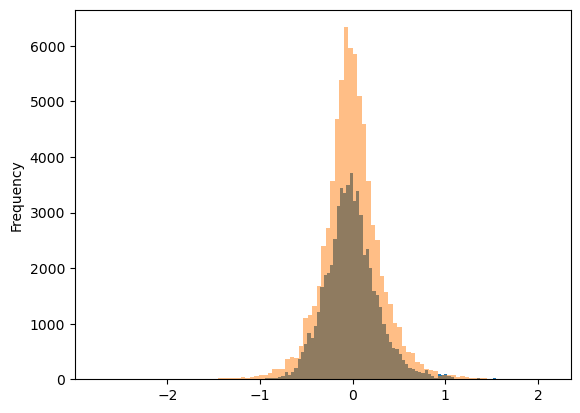

In [10]:
(df15.vorticity/df15.f).plot.hist(bins=100, label= 'naive vorticity')
(df0.vorticity/df0.f).plot.hist(bins=100, label= 'naive vorticity', alpha = 0.5)
#df.duacs_vorticity_f.plot.hist(bins=100, label= 'duacs vorticity', alpha=0.5)
#plt.legend()

In [11]:
def plot_join_pdfs(ds, x, y, binx=100, biny=100):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x],coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    plt.rcParams["axes.edgecolor"] = "k"
    fig = plt.figure(figsize=(9, 4))
    
    # Add a gridspec with two rows and two columns and a ratio of 2 to 7 between
    # the size of the marginal axes and the main axes in both directions.
    # Also adjust the subplot parameters for a square plot.
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(7, 2),
        height_ratios=(2, 7),
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.05,
        hspace=0.05,
    )
    
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
    

    from matplotlib import colors
    da.plot.pcolormesh(ax=ax, norm=colors.LogNorm(), vmin=1e0, add_colorbar=False,)
    da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    ax.plot(xx, xx, color='r')
    #ax.plot(xx, 3/4 * xx, color='orange')
    ax.plot(xx, -xx, color='r')
    ds[x].plot.hist(bins=binx, density=True, ax=ax_histx, zorder=1)
    ds[y].plot.hist(
        bins=biny,
        density=True,
        ax=ax_histy,
        orientation="horizontal",
        zorder=1,
    )


    # no labels
    ax.grid(zorder=0)
    ax_histx.grid()
    ax_histy.grid()
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_title('')
    ax_histx.set_title('')
    ax_histy.set_xlabel('')
    ax_histx.set_xlabel('')
    return fig, ax, ax_histx, ax_histy
    #fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

def plot_join_pdfs_one(ds, x, y, binx=100, biny=100, ax=None):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x], coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    plt.rcParams["axes.edgecolor"] = "k"
    
    from matplotlib import colors
    da.where(da!=0).plot.pcolormesh(ax=ax, norm=colors.LogNorm(), vmin=1e0)
    da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    ax.plot(xx, xx, color='r')
    #ax.plot(xx, 3/4 * xx, color='orange')
    ax.plot(xx, -xx, color='r')
    ax.grid()
    


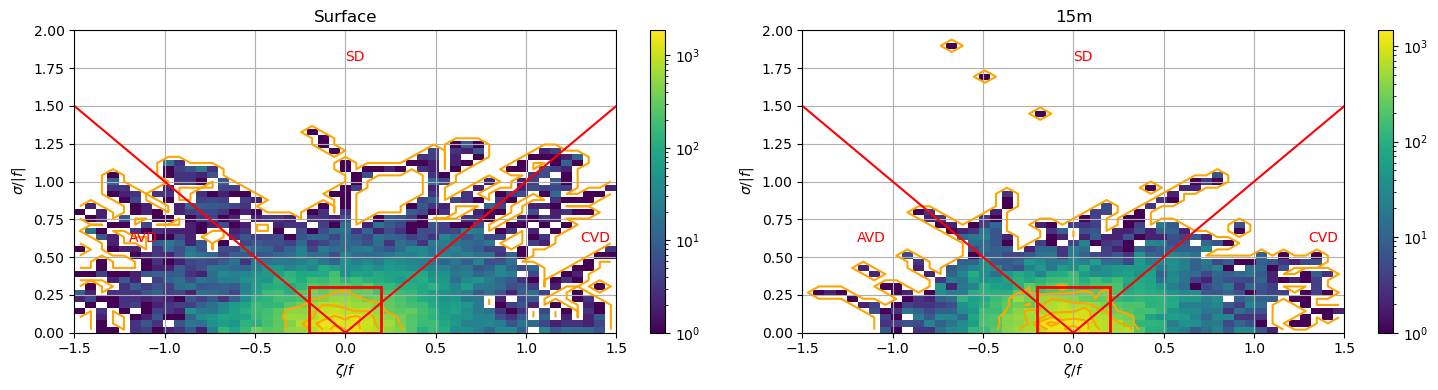

In [12]:
fig, axs = plt.subplots(1, 2, figsize =(15, 4), frameon=False)

ax=axs[0]
plot_join_pdfs_one(df0, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 2,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')

import matplotlib.patches as patches
# Create a Rectangle patch
rect = patches.Rectangle((-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor='r', facecolor='none', zorder = 10)
# Add the patch to the Axes
ax.add_patch(rect)

ax.annotate('AVD', (-1.2, 0.6), c='r')
ax.annotate('SD', (0, 1.8), c='r')
ax.annotate('CVD', (1.3, 0.6), c='r')

ax.set_title('Surface')

ax=axs[1]
plot_join_pdfs_one(df15, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 2,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')

import matplotlib.patches as patches
# Create a Rectangle patch
rect = patches.Rectangle((-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor='r', facecolor='none', zorder = 10)
# Add the patch to the Axes
ax.add_patch(rect)

ax.annotate('AVD', (-1.2, 0.6), c='r')
ax.annotate('SD', (0, 1.8), c='r')
ax.annotate('CVD', (1.3, 0.6), c='r')

ax.set_title('15m')

fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'all', f'15m_diagvortstrain_DT{DT}.png'))

/dev/shm/pbs.3474529.datarmor0/ipykernel_42167/1684253255.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df0_ = df0_[~((df0.vorticity_f<=df0.strain_f+0.15)&(df0.vorticity_f>=df0.strain_f-0.15))]
/dev/shm/pbs.3474529.datarmor0/ipykernel_42167/1684253255.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df0_ = df0_[~((df0.vorticity_f<=-df0.strain_f+0.15)&(df0.vorticity_f>=-df0.strain_f-0.15))]
/dev/shm/pbs.3474529.datarmor0/ipykernel_42167/1684253255.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df15_ = df15_[~((df15.vorticity_f<=df15.strain_f+0.15)&(df15.vorticity_f>=df15.strain_f-0.15))]
/dev/shm/pbs.3474529.datarmor0/ipykernel_42167/1684253255.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df15_ = df15_[~((df15.vorticity_f<=-df15.strain_f+0.15)&(df15.vorticity_f>=-df15.strain_f-0.15))]


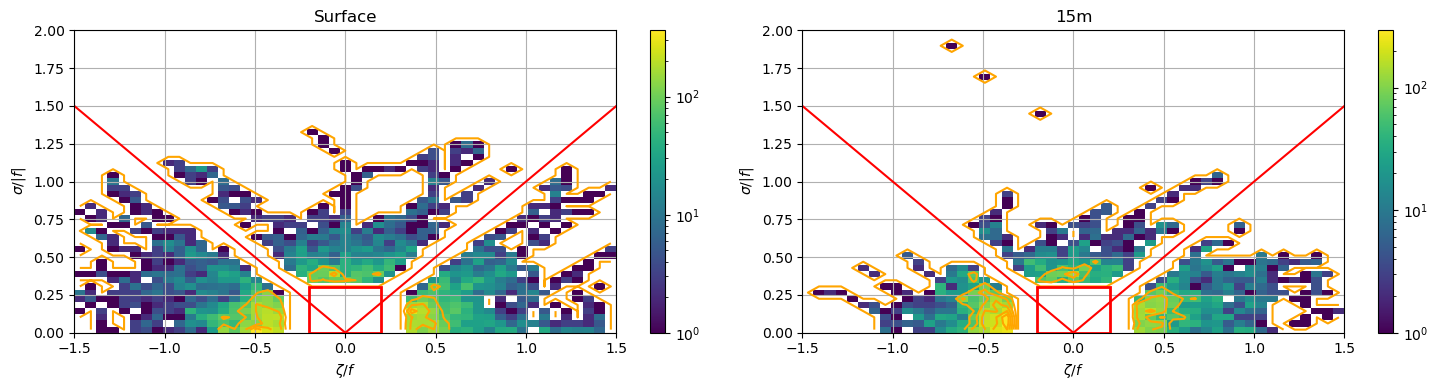

In [13]:
df0_ = df0[~((abs(df0.vorticity_f)<=0.35)&(df0.strain_f<=0.35))]
df0_ = df0_[~((df0.vorticity_f<=df0.strain_f+0.15)&(df0.vorticity_f>=df0.strain_f-0.15))]
df0_ = df0_[~((df0.vorticity_f<=-df0.strain_f+0.15)&(df0.vorticity_f>=-df0.strain_f-0.15))]
df15_ = df15[~((abs(df15.vorticity_f)<=0.35)&(df15.strain_f<=0.35))]
df15_ = df15_[~((df15.vorticity_f<=df15.strain_f+0.15)&(df15.vorticity_f>=df15.strain_f-0.15))]
df15_ = df15_[~((df15.vorticity_f<=-df15.strain_f+0.15)&(df15.vorticity_f>=-df15.strain_f-0.15))]


plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(1, 2, figsize =(15, 4), frameon=False)

ax = axs[0]
plot_join_pdfs_one(df0_, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 2,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')
import matplotlib.patches as patches
# Create a Rectangle patch
rect = patches.Rectangle((-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor='r', facecolor='none', zorder = 10)
# Add the patch to the Axes
ax.add_patch(rect)
ax.set_title('Surface')


ax = axs[1]
plot_join_pdfs_one(df15_, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 2,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')
import matplotlib.patches as patches
# Create a Rectangle patch
rect = patches.Rectangle((-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor='r', facecolor='none', zorder = 10)
# Add the patch to the Axes
ax.add_patch(rect)
ax.set_title('15m')


fig.tight_layout()


____
# Closure

In [14]:
DSz0 = {'AVD': df0_[(df0_.vorticity<0) & (df0_.strain<abs(df0_.vorticity))].to_xarray(), 
       'CVD': df0_[(df0_.vorticity>0) & (df0_.strain<abs(df0_.vorticity))].to_xarray(), 
       'SD': df0_[df0_.strain>=abs(df0_.vorticity)].to_xarray()}

DSz15 = {'AVD': df15_[(df15_.vorticity<0) & (df15_.strain<abs(df15_.vorticity))].to_xarray(), 
       'CVD': df15_[(df15_.vorticity>0) & (df15_.strain<abs(df15_.vorticity))].to_xarray(), 
       'SD': df15_[df15_.strain>=abs(df15_.vorticity)].to_xarray()}

/dev/shm/pbs.3474529.datarmor0/ipykernel_42167/3857551764.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz15[k].dims['row_number'])


5019


/dev/shm/pbs.3474529.datarmor0/ipykernel_42167/3857551764.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz15[k].dims['row_number'])


4197


/dev/shm/pbs.3474529.datarmor0/ipykernel_42167/3857551764.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz15[k].dims['row_number'])


2059
6.848095792346488
7.3784352780088875
8.117103292193558
8.38552597556263
8.571894397900975
8.762735914087283


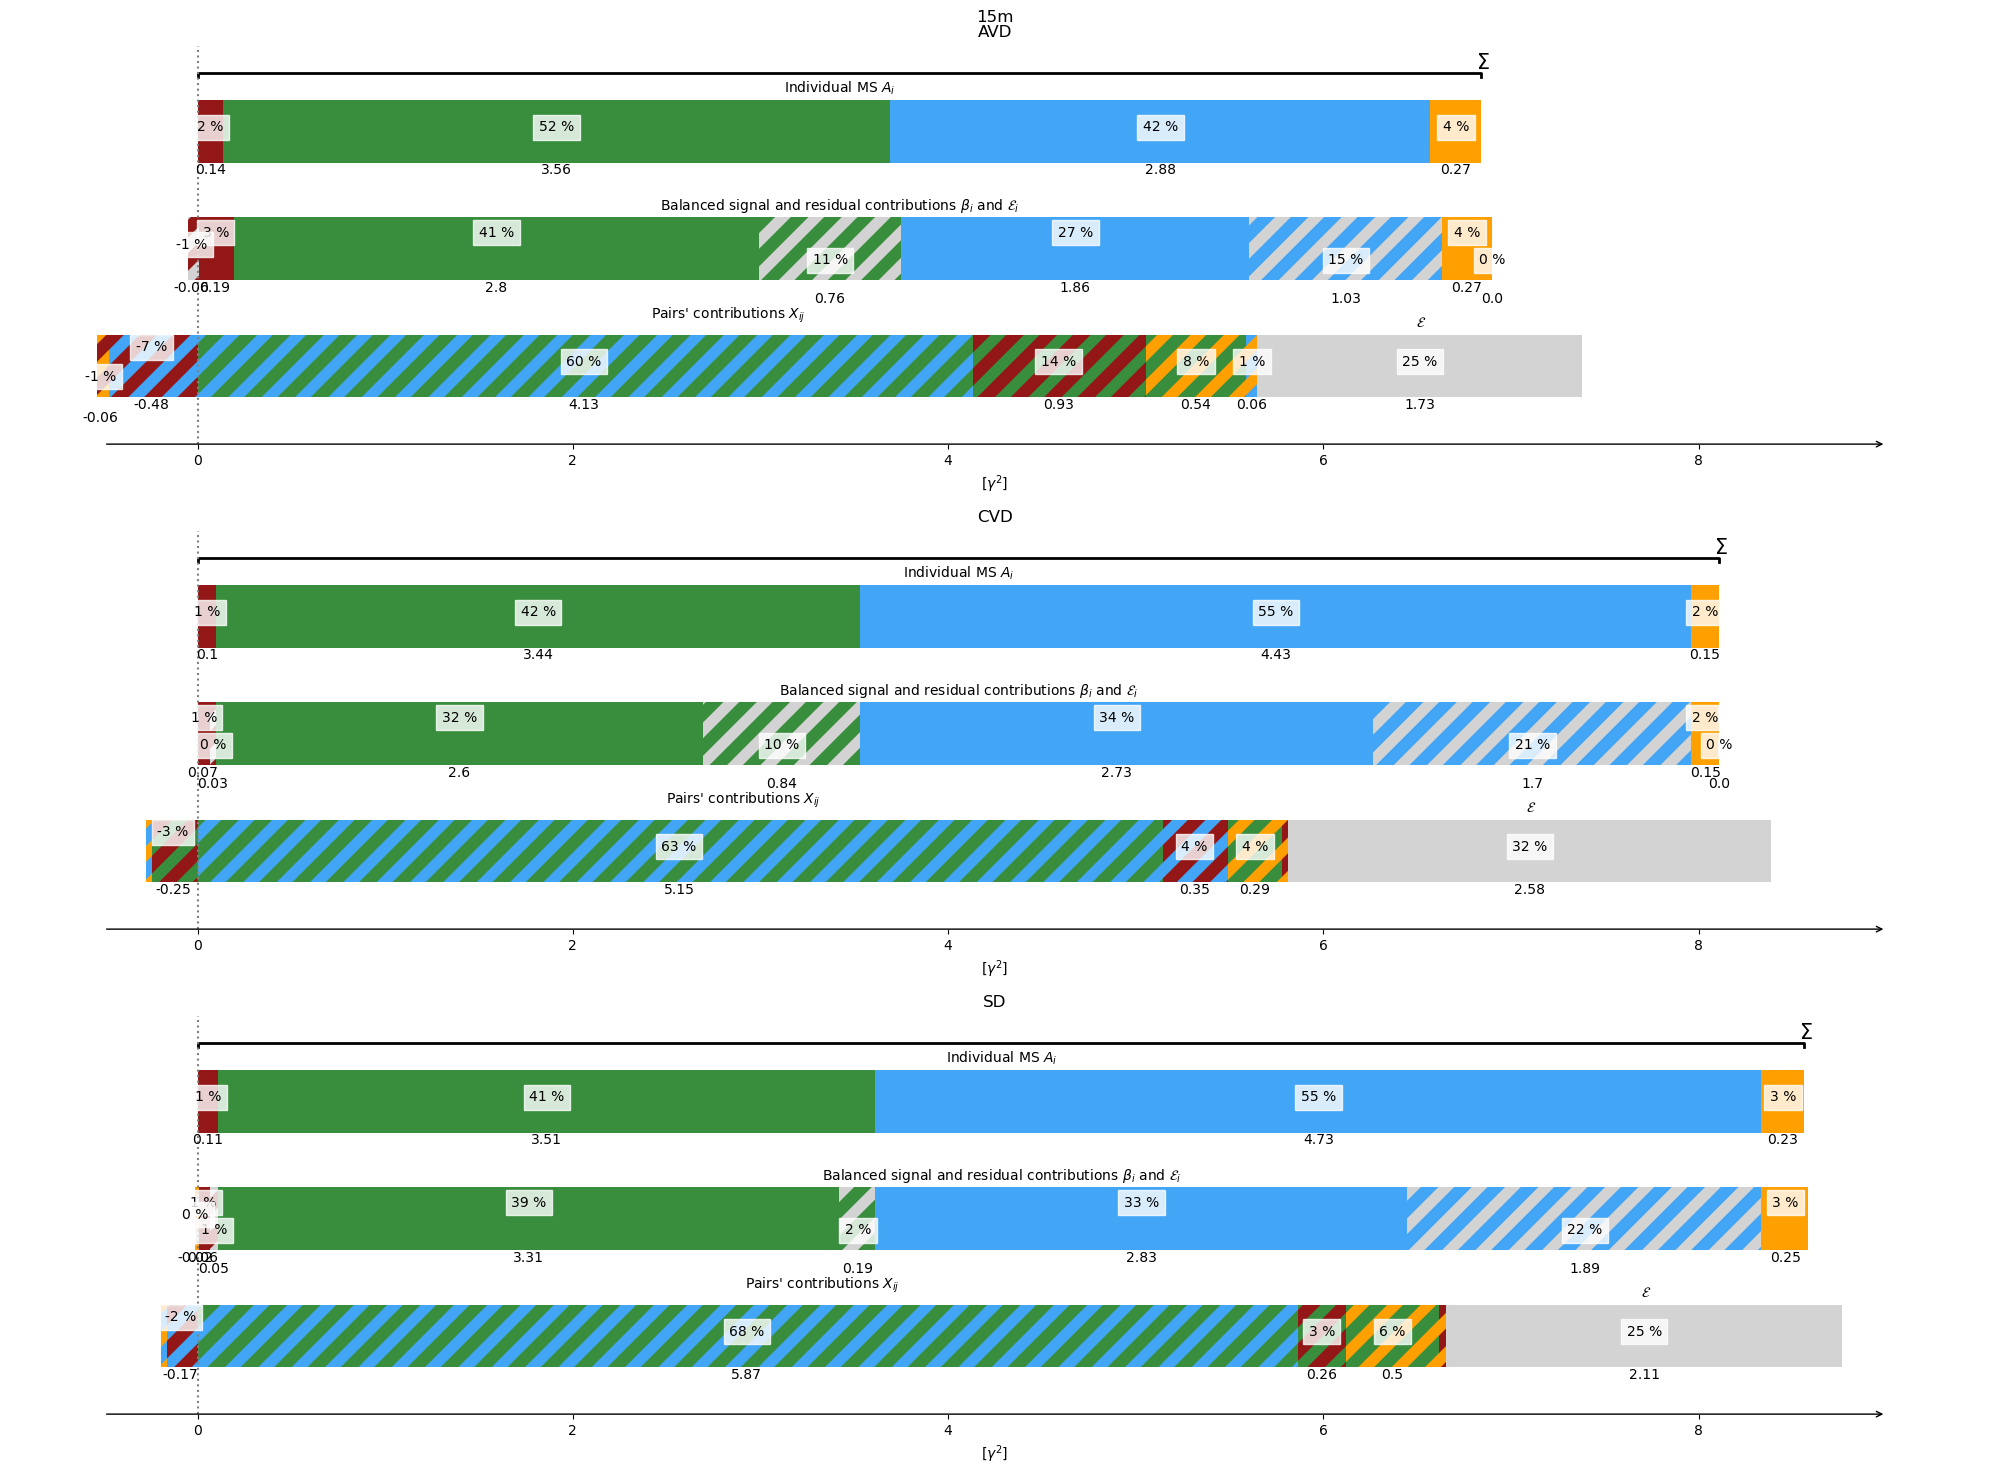

In [15]:
D = []
# Closure figs
for k in DSz15:
    print(DSz15[k].dims['row_number'])
    D.append(compute_variance(DSz15[k])/U2)
dsz = xr.concat(D, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))
dfz =dsz.to_dataframe()

plt.rcParams["axes.edgecolor"] = "w"
fig, axs = plt.subplots(nrows=3,ncols=1,figsize=(20,15), frameon=False)
i = 0
for d in dfz.index :
    synthetic_figure(dfz.loc[d], axs[i], dir='', xlim=[-1, 9])
    axs[i].set_title(d)
    i+=1
fig.suptitle('15m')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'all', '15m_closure_avdcvdsd.png'))

In [16]:
DSz0['AVD'].drop_vars('time_to_swot').mean()/DSz0['AVD'].drop_vars('time_to_swot').std()

<xarray.Dataset> Size: 368B
Dimensions:            ()
Data variables: (12/46)
    sume               float64 8B 0.1962
    acce               float64 8B -0.003448
    exce_acc           float64 8B 0.1925
    core               float64 8B 0.3584
    exce_cor           float64 8B -0.1611
    ggde               float64 8B 0.03812
    ...                 ...
    f                  float64 8B 55.81
    strain_f           float64 8B 1.057
    strain             float64 8B 1.063
    vorticity          float64 8B -2.461
    vorticity_f        float64 8B -2.451
    omega              float64 8B -0.8376

/dev/shm/pbs.3474529.datarmor0/ipykernel_42167/2247845178.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz0[k].dims['row_number'])


6256


/dev/shm/pbs.3474529.datarmor0/ipykernel_42167/2247845178.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz0[k].dims['row_number'])


5812


/dev/shm/pbs.3474529.datarmor0/ipykernel_42167/2247845178.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz0[k].dims['row_number'])


3186
10.80716057468013
11.578590897230292
8.897813825046214
8.973908490098987
11.391457500321192
11.860285482915568


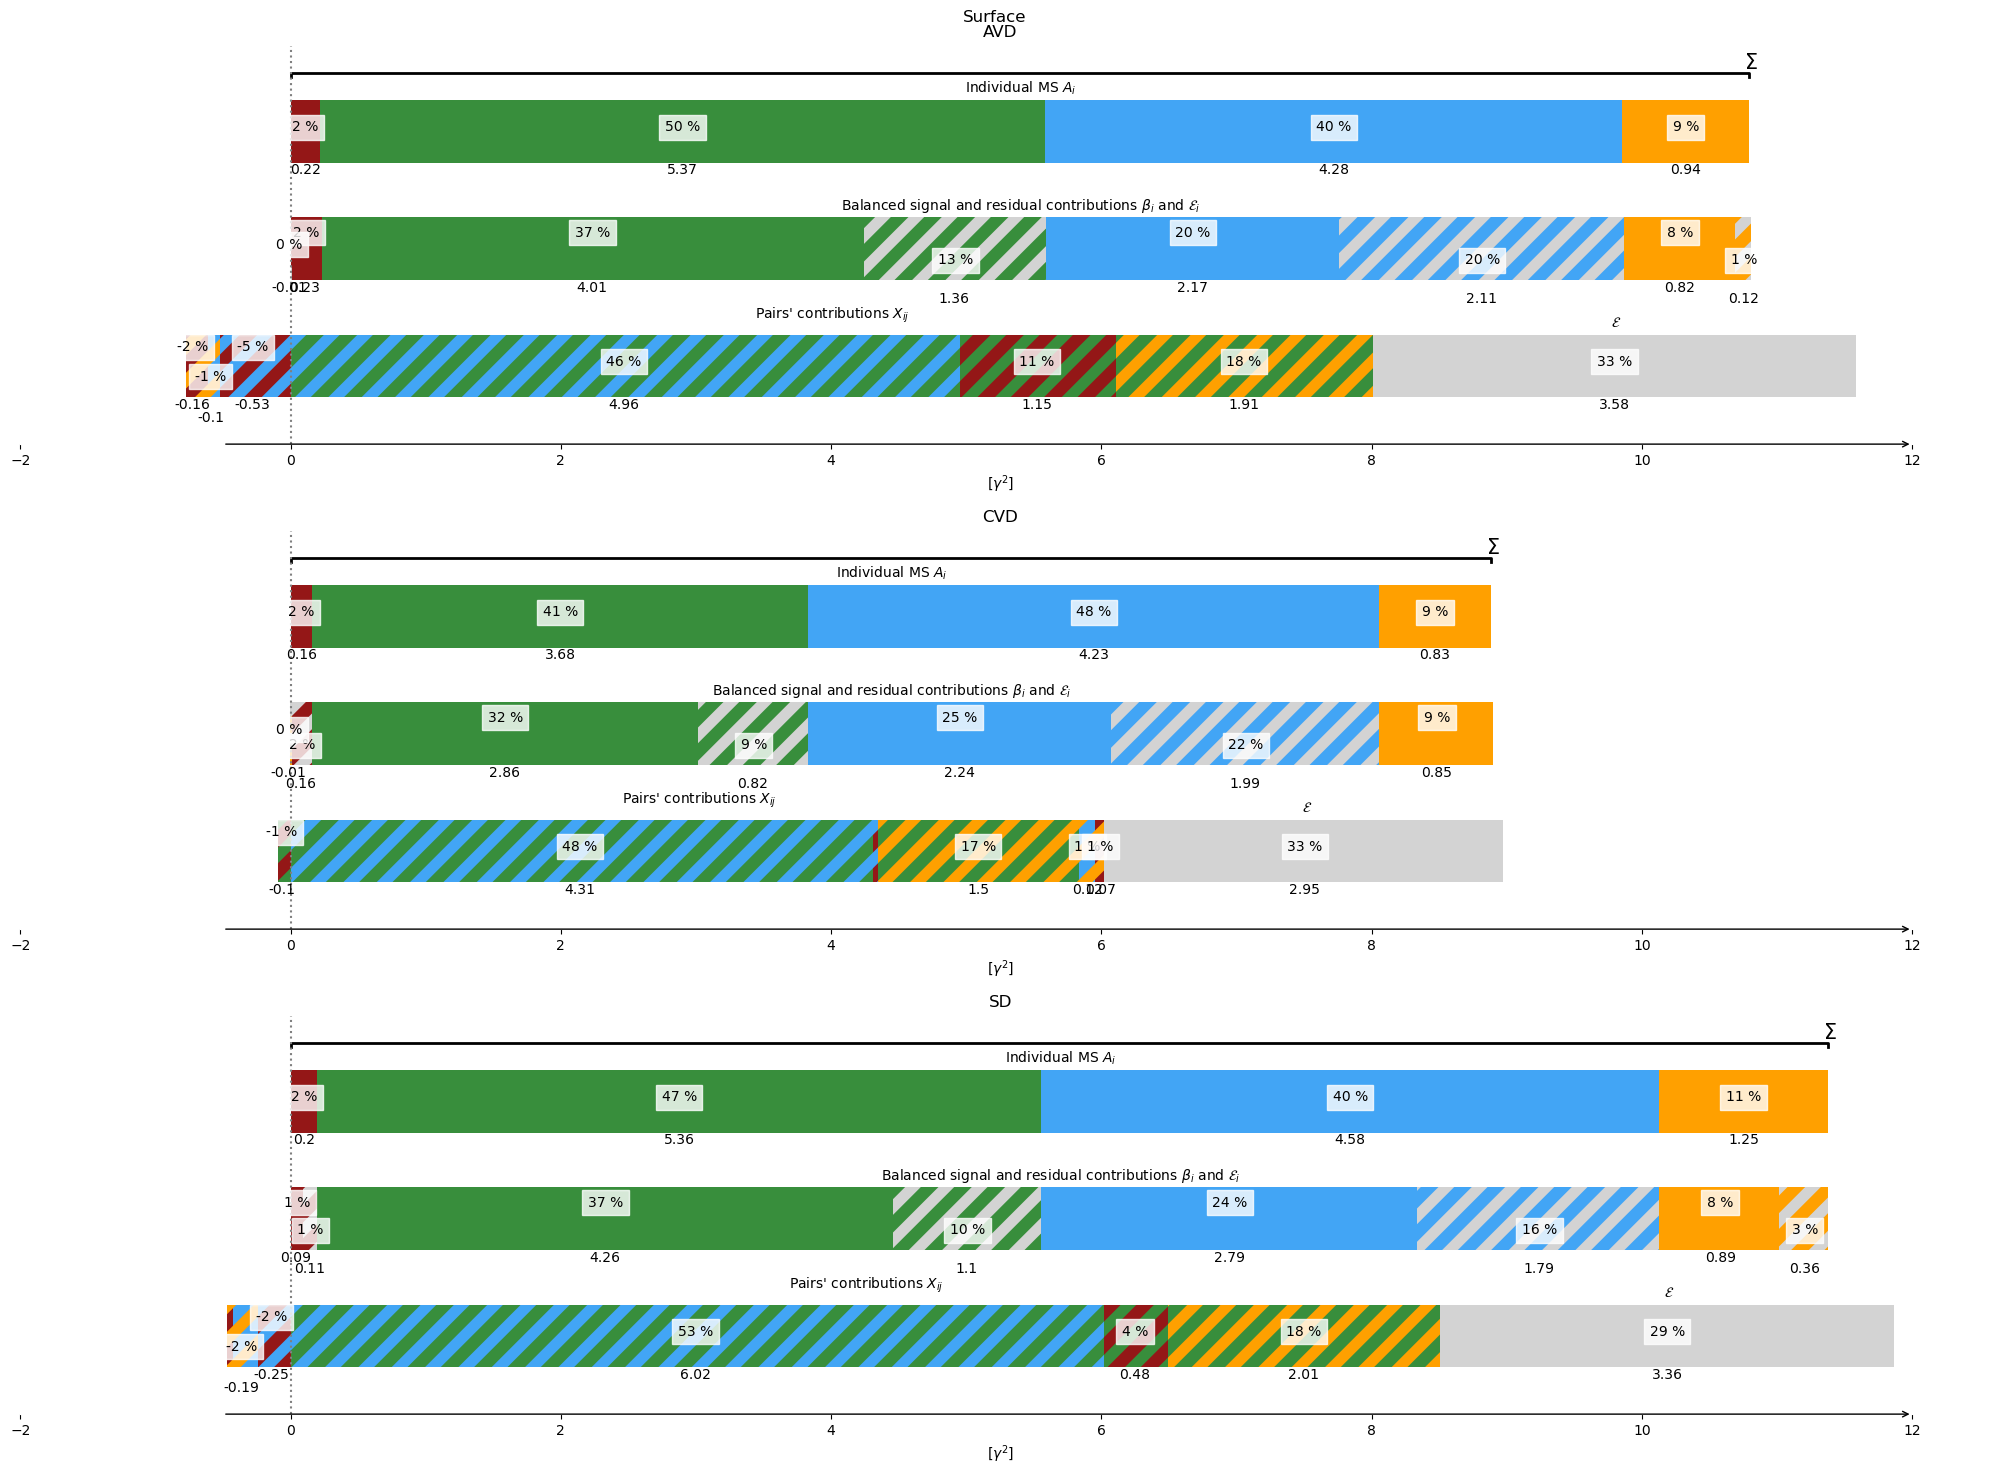

In [17]:
D = []
# Closure figs
for k in DSz0:
    print(DSz0[k].dims['row_number'])
    D.append(compute_variance(DSz0[k])/U2)
dsz = xr.concat(D, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))
dfz =dsz.to_dataframe()


plt.rcParams["axes.edgecolor"] = "w"
fig, axs = plt.subplots(nrows=3,ncols=1,figsize=(20,15), frameon=False)
i = 0
for d in dfz.index :
    synthetic_figure(dfz.loc[d], axs[i], dir='', xlim=[-2, 12])
    axs[i].set_title(d)
    i+=1
fig.suptitle('Surface')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'all', '15m_closure_avdcvdsd.png'))

_________
# Where ?

In [18]:
Dll = []
dl=0.05
lonbins = np.arange(0.9, 6.1, dl)
latbins = np.arange(37.9, 43.4, dl)
for k in DSz:
    dfl = DSz[k].to_dataframe()
    dfl['longitude_cut']= pd.cut(dfl['longitude'], lonbins, labels=(lonbins[1:] + lonbins[:-1])/2)
    dfl['latitude_cut']= pd.cut(dfl['latitude'], latbins, labels=(latbins[1:] + latbins[:-1])/2)
    Dll.append(compute_variance_groupby(dfl, groupby = ['latitude_cut', 'longitude_cut'], dirname = ('e', 'n'),  vars_errors=None))

dll = xr.concat(Dll, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))

plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(1,3, sharey=True, frameon = False, figsize = (15, 5), subplot_kw={'projection':ccrs.Orthographic(1.6,39.5)})
i=0
for d in dll.dyn.values:
    ax=axs[i]
    dll.sel(dyn=d).where(dll.sel(dyn=d).nb_coloc!=0).nb_coloc.assign_attrs(long_name='Number of coloc per 0.02° bins').plot(ax=ax, transform=crs)
    ax.set_title(d)
    i+=1

for ax in axs : 
    gl = ax.gridlines(draw_labels=True,)
    gl.top_labels=False   # suppress top labels
    gl.right_labels=False
    #ax.add_feature(cfeature.LAND,)

fig.tight_layout()


NameError: name 'DSz' is not defined

____
# BIOSWOT-SWOT anticyclonic eddy

In [19]:
dfa = df0[(df0.latitude>40)&(df0.latitude<41.3)&(df0.longitude>4.5)&(df0.longitude<5.5)]

In [20]:
Dll = []
dl=0.02
lonbins = np.arange(4.5, 5.5, dl)
latbins = np.arange(40, 41.3, dl)

dfa['longitude_cut']= pd.cut(dfa['longitude'], lonbins, labels=(lonbins[1:] + lonbins[:-1])/2)
dfa['latitude_cut']= pd.cut(dfa['latitude'], latbins, labels=(latbins[1:] + latbins[:-1])/2)
#dsa = compute_variance_groupby(dfa, groupby = ['latitude_cut', 'longitude_cut'], dirname = ('e', 'n'), bootstrap = False, vars_errors=None))
dsam = dfa[['longitude_cut','latitude_cut','strain', 'strain_f','vorticity_f', 'omega']].groupby(['longitude_cut','latitude_cut' ], observed=False).mean().to_xarray()

/dev/shm/pbs.3474529.datarmor0/ipykernel_42167/2012447464.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfa['longitude_cut']= pd.cut(dfa['longitude'], lonbins, labels=(lonbins[1:] + lonbins[:-1])/2)
/dev/shm/pbs.3474529.datarmor0/ipykernel_42167/2012447464.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfa['latitude_cut']= pd.cut(dfa['latitude'], latbins, labels=(latbins[1:] + latbins[:-1])/2)


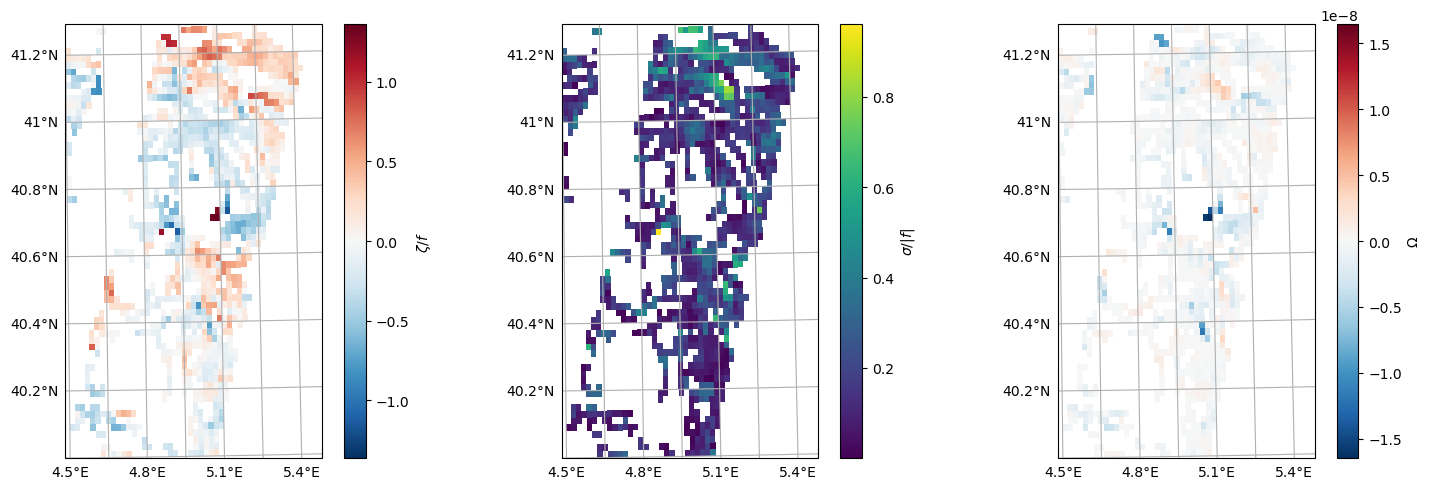

In [21]:
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(1,3, sharey=True, frameon = False, figsize = (15, 5), subplot_kw={'projection':ccrs.Orthographic(3.5,40.5)})
ax=axs[0]
dsam.vorticity_f.assign_attrs(long_name=r'$\zeta/f$').plot(ax=ax,x='longitude_cut', y='latitude_cut', transform=crs)

ax=axs[1]
dsam.strain_f.assign_attrs(long_name=r'$\sigma/|f|$').plot(ax=ax,x='longitude_cut', y='latitude_cut', transform=crs)

ax=axs[2]
dsam.omega.assign_attrs(long_name=r'$\Omega$').plot(ax=ax,x='longitude_cut', y='latitude_cut', transform=crs)

for ax in axs : 
    gl = ax.gridlines(draw_labels=True,)
    gl.top_labels=False   # suppress top labels
    gl.right_labels=False
    #ax.add_feature(cfeature.LAND,)

fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'bioswot', f'bioswot_15m_geo_vorticitystrain_DT{DT}.png'))

(<Figure size 900x400 with 3 Axes>,
 <Axes: xlabel='vorticity_f', ylabel='strain_f'>,
 <Axes: ylabel='Frequency'>,
 <Axes: >)

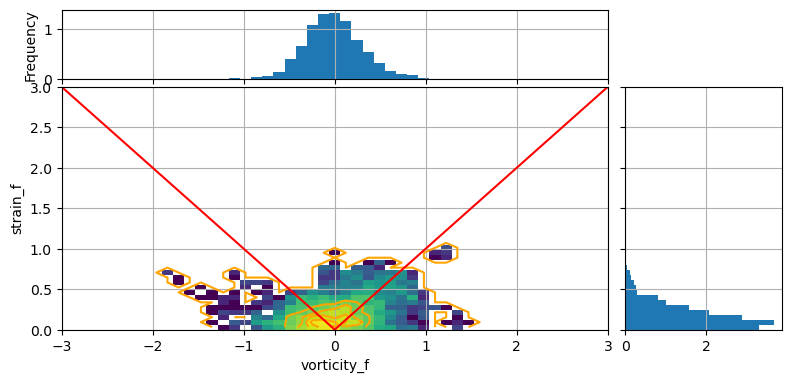

In [32]:
plot_join_pdfs(dfa, 'vorticity_f', 'strain_f', binx=np.linspace(-3, 3, 50), biny=np.linspace(0, 3,50))

In [33]:
DSaz = {'AVD': dfa[(dfa.vorticity<0) & (dfa.strain<abs(dfa.vorticity))].to_xarray(), 
       'CVD': dfa[(dfa.vorticity>0) & (dfa.strain<abs(dfa.vorticity))].to_xarray(), 
       'SD': dfa[dfa.strain>=abs(dfa.vorticity)].to_xarray()}

In [34]:
D = []
# Closure figs
for k in DSaz:
    print(DSaz[k].dims['row_number'])
    D.append(compute_variance(DSaz[k])/U2)
dsaz = xr.concat(D, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))
dfaz =dsaz.to_dataframe()

/dev/shm/pbs.2887126.datarmor0/ipykernel_56052/1806971662.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSaz[k].dims['row_number'])


6174
ok
geostrophic mean corrections


/dev/shm/pbs.2887126.datarmor0/ipykernel_56052/1806971662.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSaz[k].dims['row_number'])


3982
ok
geostrophic mean corrections


/dev/shm/pbs.2887126.datarmor0/ipykernel_56052/1806971662.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSaz[k].dims['row_number'])


6832
ok
geostrophic mean corrections


In [35]:
Dll = []
dl=0.02
lonbins = np.arange(4.5, 5.5, dl)
latbins = np.arange(40, 41.3, dl)
for k in DSaz:
    dfl = DSaz[k].to_dataframe()
    dfl['longitude_cut']= pd.cut(dfl['longitude'], lonbins, labels=(lonbins[1:] + lonbins[:-1])/2)
    dfl['latitude_cut']= pd.cut(dfl['latitude'], latbins, labels=(latbins[1:] + latbins[:-1])/2)
    Dll.append(compute_variance_groupby(dfl, groupby = ['latitude_cut', 'longitude_cut'], dirname = ('e', 'n'), vars_errors=None))

dll = xr.concat(Dll, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))

ok
geostrophic mean corrections
ok
geostrophic mean corrections
ok
geostrophic mean corrections


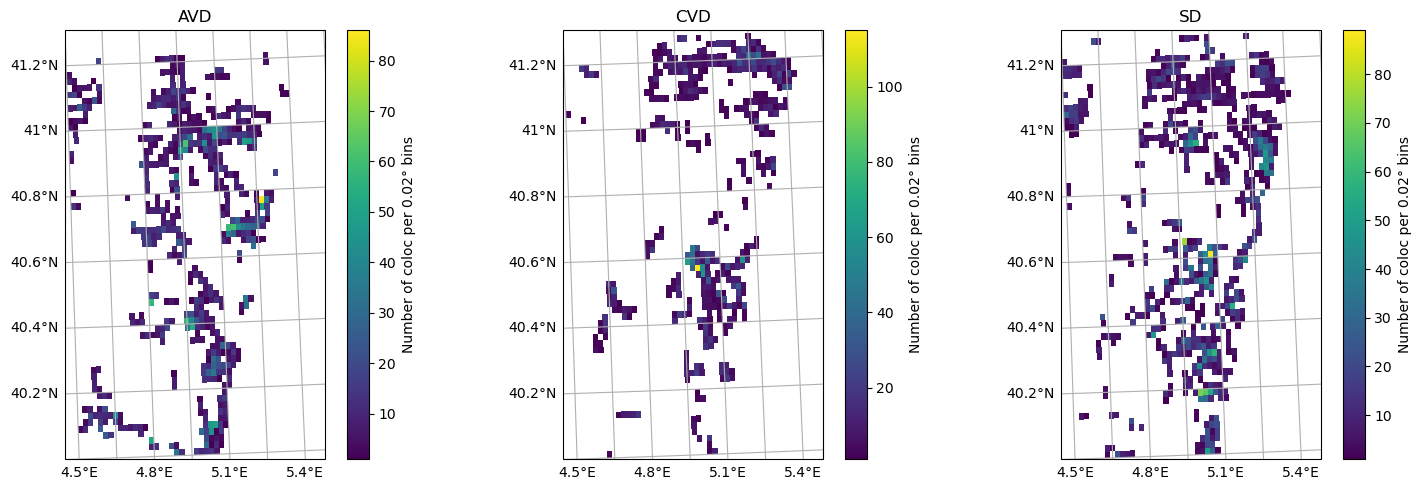

In [36]:
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(1,3, sharey=True, frameon = False, figsize = (15, 5), subplot_kw={'projection':ccrs.Orthographic(1.6,39.5)})
i=0
for d in dll.dyn.values:
    ax=axs[i]
    dll.sel(dyn=d).where(dll.sel(dyn=d).nb_coloc!=0).nb_coloc.assign_attrs(long_name='Number of coloc per 0.02° bins').plot(ax=ax, transform=crs)
    ax.set_title(d)
    i+=1

for ax in axs : 
    gl = ax.gridlines(draw_labels=True,)
    gl.top_labels=False   # suppress top labels
    gl.right_labels=False
    #ax.add_feature(cfeature.LAND,)

fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'bioswot', f'bioswot_15m_geo_avdcvdsd_DT{DT}.png'))

22.845810947670305
27.318147454686088
23.70197464819548
26.580105361248854
22.756810184630485
25.73186893074882


/dev/shm/pbs.2887126.datarmor0/ipykernel_1494/3189066457.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


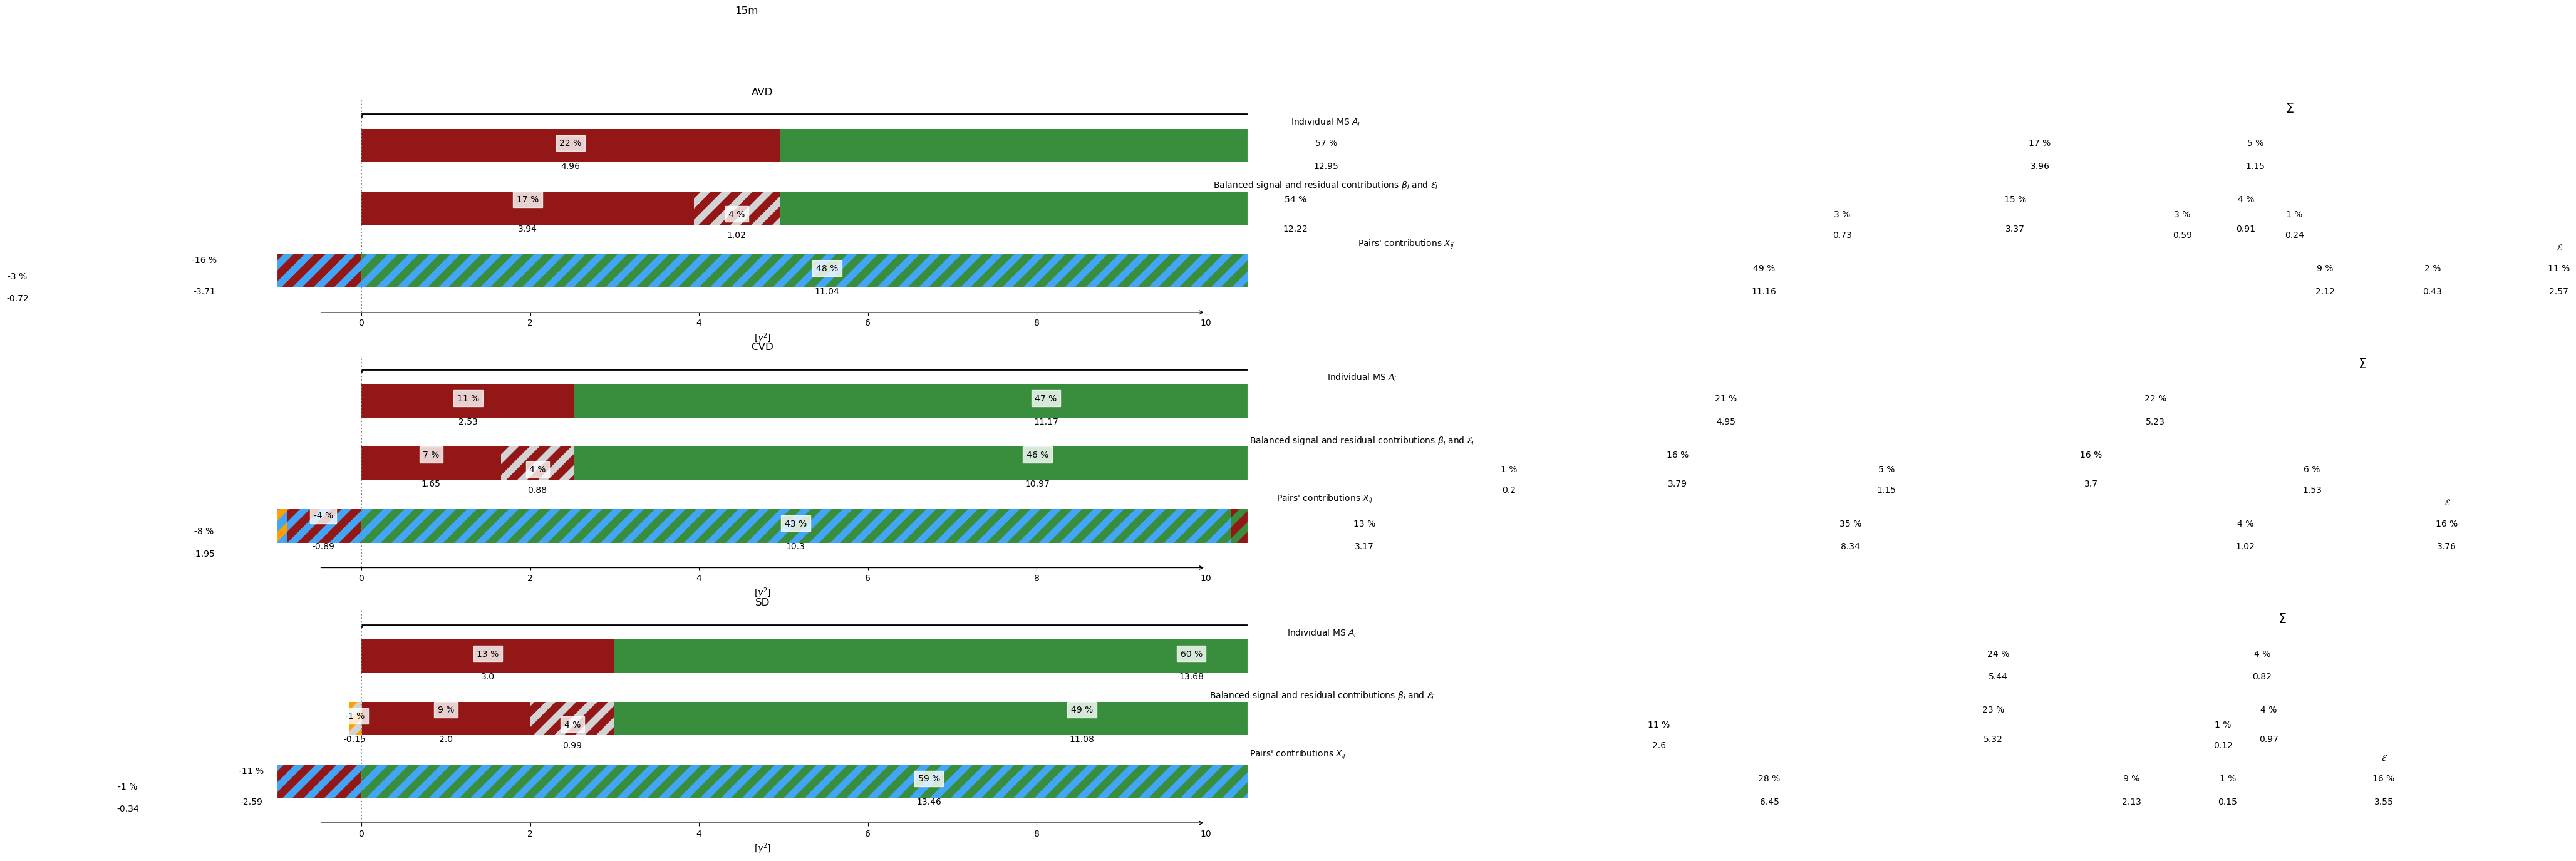

In [81]:
plt.rcParams["axes.edgecolor"] = "w"
fig, axs = plt.subplots(nrows=3,ncols=1,figsize=(20,15), frameon=False)
i = 0
for d in dfaz.index :
    synthetic_figure(dfaz.loc[d], axs[i], dir='', xlim=[-1, 10])
    axs[i].set_title(d)
    i+=1
fig.suptitle('15m')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'bioswot', f'bioswot_15m_closure_avdcvdsd_DT{DT}.png'))

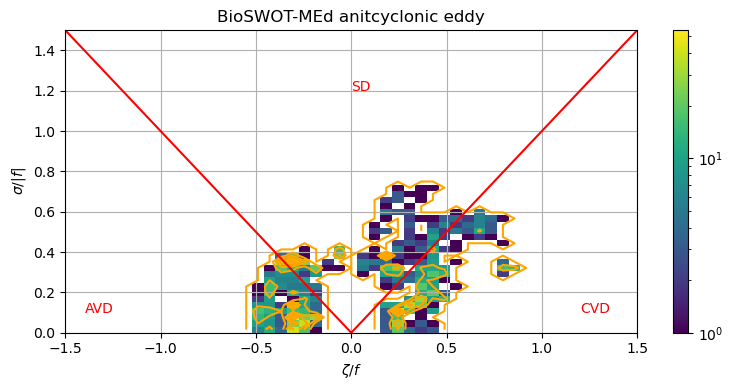

In [83]:
fig, ax = plot_join_pdfs_one(dfa, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 1.5,50))
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')

ax.annotate('AVD', (-1.4, 0.1), c='r')
ax.annotate('SD', (0, 1.2), c='r')
ax.annotate('CVD', (1.2, 0.1), c='r')
ax.set_title('BioSWOT-MEd anitcyclonic eddy')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'bioswot', f'bioswot_15m_diagvortstrain_DT{DT}.png'))